# PV Forecasting — 4. Visual Inspection

**Purpose:** visually inspect the power signal over time and against irradiance to spot outages, sensor dropouts, and the overall shape of the data before deciding how to clean it.

**Input:** `../Output/checkpoint_02_quality.pkl`

**Output:** none

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "../Output"

In [2]:
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_02_quality.pkl")
df.shape

(5832, 30)

## 5.1 Power over time

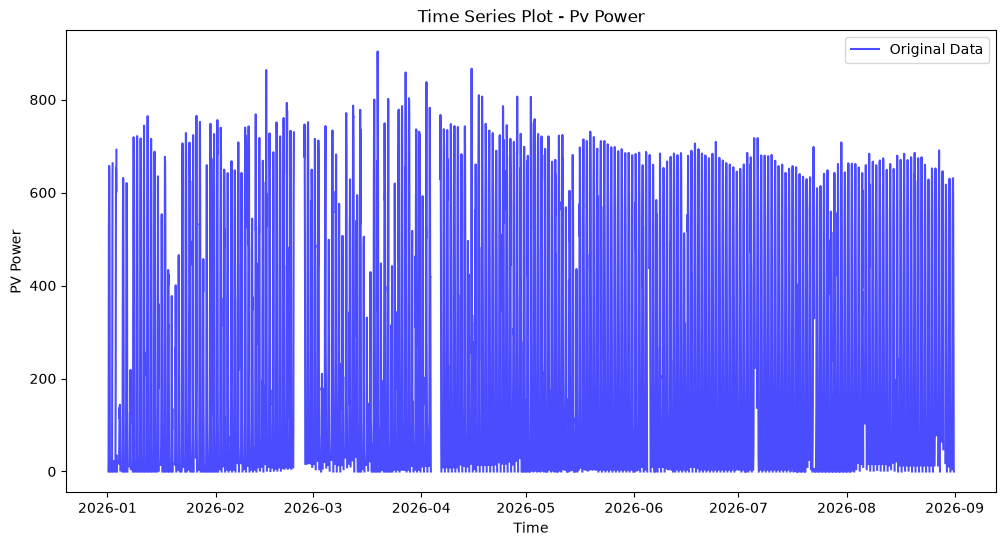

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df["Timestamp"], df['PV_Total_Power_W'], label="Original Data", color="blue", alpha=0.7)
plt.xlabel("Time")
plt.ylabel('PV Power')
plt.title("Time Series Plot - Pv Power")
plt.legend()
plt.show()

## 5.2 Power by month

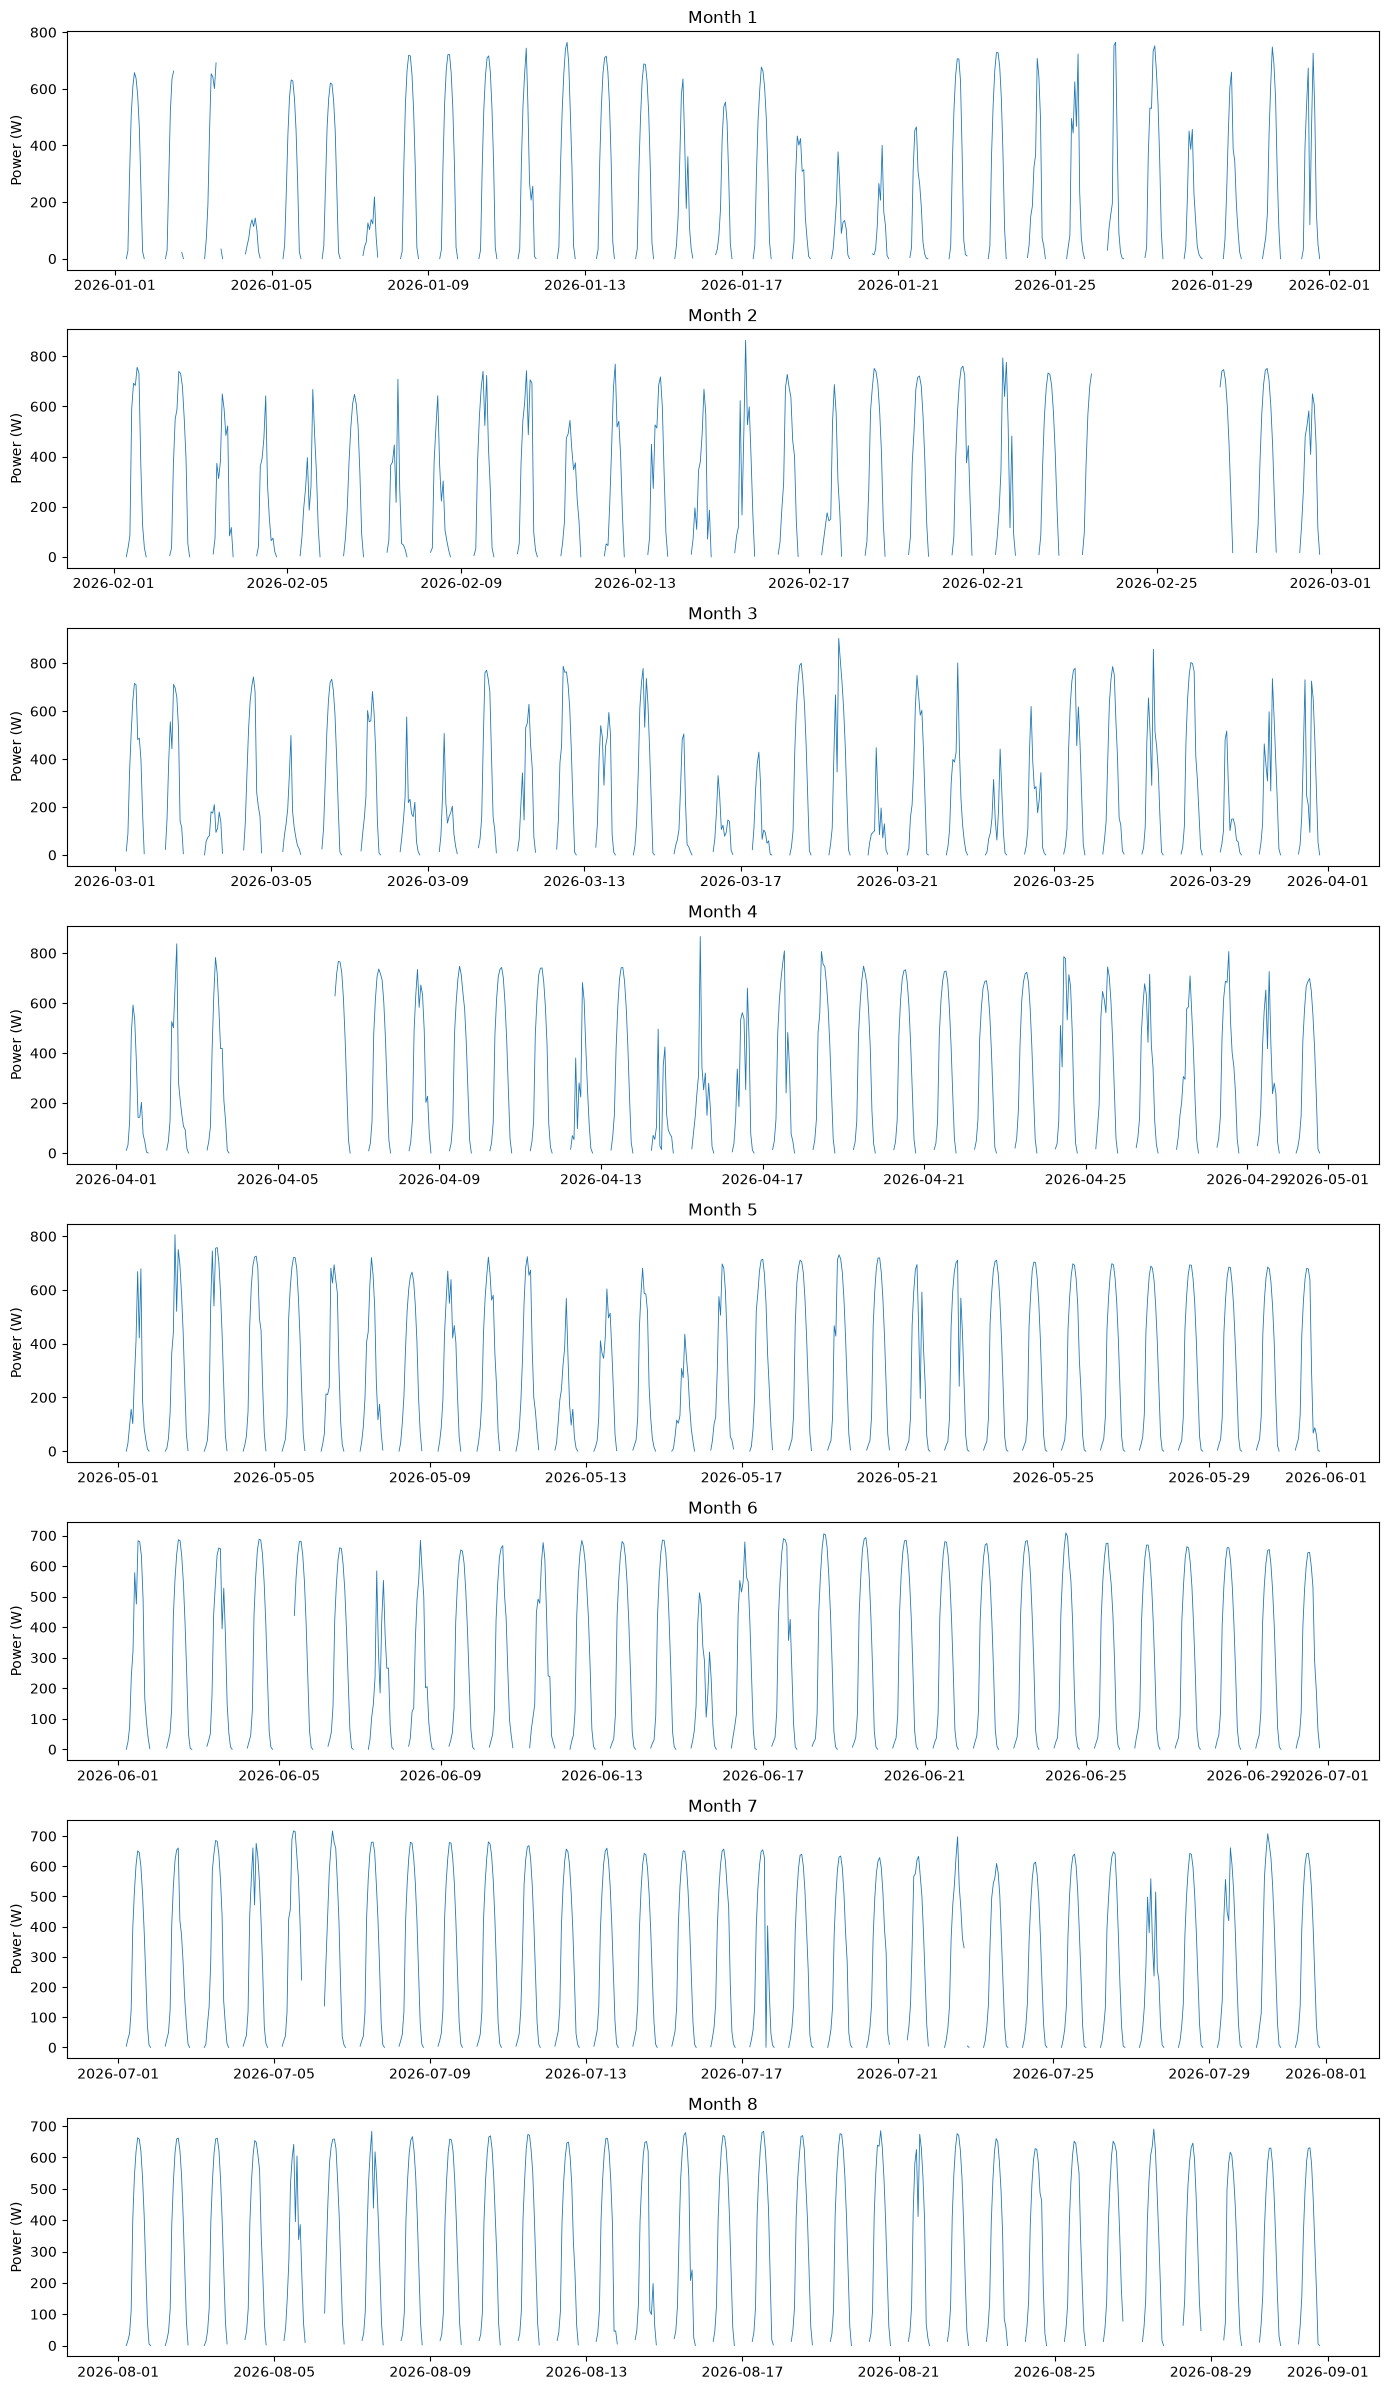

In [3]:
months = sorted(df["month"].unique())
n = len(months)

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]  # keep it iterable when there's only one month

for ax, m in zip(axes, months):
    month_data = df[df["month"] == m]
    ax.plot(month_data["Timestamp"], month_data["PV_Total_Power_W"], linewidth=0.6)
    ax.set_title(f"Month {m}")
    ax.set_ylabel("Power (W)")

plt.tight_layout()
plt.show()

**Observations:**
- Looking at Month 2 and Month 4: some days with no peak at all, not just a ragged/cloudy-looking curve or nighttime. That's not weather, that's the sensor/logger being down for multiple consecutive days (maybe no wifi or no electricity or ELK down).
- Other months (8, 7, 6, 1, 2), there are missing data in daytime.

## 5.3 Power vs. Irradiance

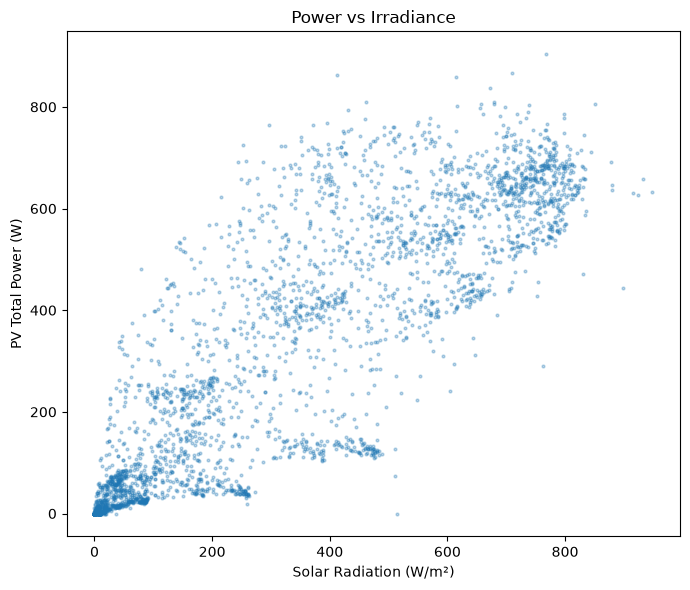

In [5]:
plt.figure(figsize=(7, 6))
plt.scatter(df["Solar_Radiation_Wm2"], df["PV_Total_Power_W"], s=4, alpha=0.3)
plt.xlabel("Solar Radiation (W/m²)")
plt.ylabel("PV Total Power (W)")
plt.title("Power vs Irradiance")
plt.tight_layout()
plt.show()

## 5.4 Distribution of key variables

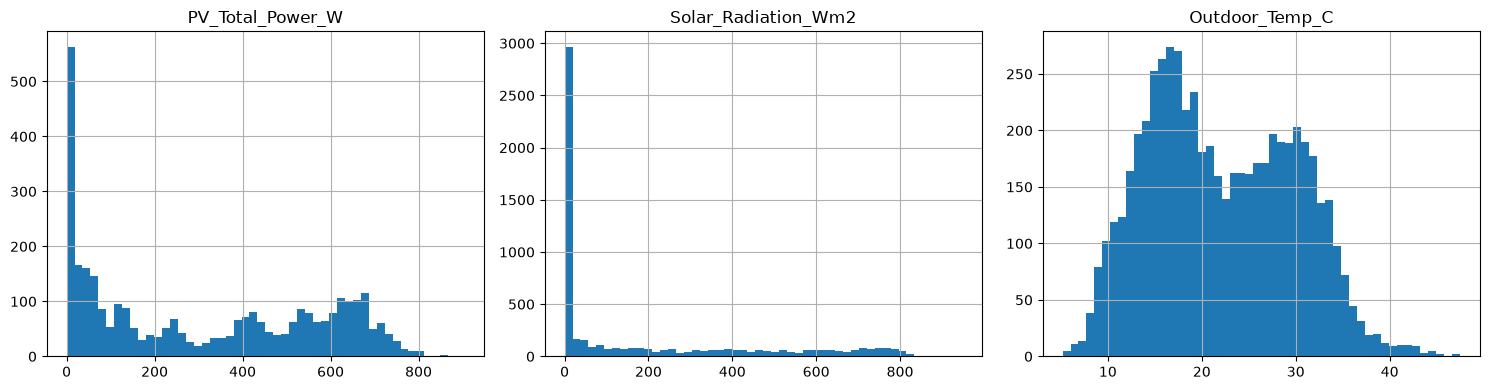

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["PV_Total_Power_W"].dropna().hist(bins=50, ax=axes[0])
axes[0].set_title("PV_Total_Power_W")
df["Solar_Radiation_Wm2"].dropna().hist(bins=50, ax=axes[1])
axes[1].set_title("Solar_Radiation_Wm2")
df["Outdoor_Temp_C"].dropna().hist(bins=50, ax=axes[2])
axes[2].set_title("Outdoor_Temp_C")
plt.tight_layout()
plt.show()